In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load and Inspect Data

In [15]:
# 1. Load the dataset
df = pd.read_csv('/Users/kusum/Desktop/MDS/Second Sem/Applied Machine Learning/AML/data/Gaming_Hours_vs_Academic_Performance.csv')

#text columns (like 'Gender') has been avoided with the use of most relevant numerical features.
features = ['Daily_Gaming_Hours', 'Sleep_Hours', 'Stress_Level', 'Academic_or_Work_Score']

# 2. Prepare Input (X)
X = df[features].values

# 3. Prepare Target (y)
# If 'Negative' -> 1, Else (Neutral/Positive) -> 0
y = np.where(df['Performance_Impact'] == 'Negative', 1, 0)
y = y.reshape(-1, 1) # Reshape to be a column vector (N, 1)

print(f"Features selected: {features}")
print(f"Input Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print(f"Class Balance: {np.sum(y)} Negatives out of {len(y)} total")

Features selected: ['Daily_Gaming_Hours', 'Sleep_Hours', 'Stress_Level', 'Academic_or_Work_Score']
Input Shape: (1000, 4)
Target Shape: (1000, 1)
Class Balance: 135 Negatives out of 1000 total


## 2. Preprocessing (Normalization & Splitting)

In [16]:
# Normalization (Min-Max Scaling): (value - min) / (max - min)
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)
X_norm = (X - X_min) / (X_max - X_min)

# Train/Test Split (80% Train, 20% Test) with shuffled indices to ensure random sampling
indices = np.arange(len(X))
np.random.shuffle(indices)

split_idx = int(len(X) * 0.8)
train_indices, test_indices = indices[:split_idx], indices[split_idx:]

X_train, X_test = X_norm[train_indices], X_norm[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

Training Data: (800, 4)
Testing Data: (200, 4)


## 3. The Neural Network Class

In [17]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        np.random.seed(42)
        # Initialize weights
        self.weights_input_hidden = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.weights_hidden_output = np.random.uniform(-1, 1, (hidden_size, output_size))
        # Initialize biases
        self.bias_hidden = np.zeros((1, hidden_size))
        self.bias_output = np.zeros((1, output_size))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        # Layer 1
        self.hidden_output = self.sigmoid(np.dot(X, self.weights_input_hidden) + self.bias_hidden)
        # Layer 2
        self.final_output = self.sigmoid(np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output)
        return self.final_output

    def backward(self, X, y, learning_rate):
        # Calculate Gradients
        error = y - self.final_output
        d_output = error * self.sigmoid_derivative(self.final_output)
        
        error_hidden = d_output.dot(self.weights_hidden_output.T)
        d_hidden = error_hidden * self.sigmoid_derivative(self.hidden_output)
        
        # Update Weights
        self.weights_hidden_output += self.hidden_output.T.dot(d_output) * learning_rate
        self.bias_output += np.sum(d_output, axis=0, keepdims=True) * learning_rate
        self.weights_input_hidden += X.T.dot(d_hidden) * learning_rate
        self.bias_hidden += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    def train(self, X, y, epochs, learning_rate):
        loss_history = []
        for epoch in range(epochs):
            self.forward(X)
            self.backward(X, y, learning_rate)
            
            if epoch % 100 == 0:
                loss = np.mean(np.square(y - self.final_output))
                loss_history.append(loss)
                if epoch % 1000 == 0:
                    print(f"Epoch {epoch} | Loss: {loss:.5f}")
        return loss_history

## 4. Training and Prediction

In [18]:
# Initialize Network
nn = NeuralNetwork(input_size=4, hidden_size=8, output_size=1)

print("Starting Training")
# Lower learning rate slightly for real data, higher epochs
loss_curve = nn.train(X_train, y_train, epochs=10000, learning_rate=0.01)

# Evaluate on Test Set
print("\n Evaluation on Test Set")
predictions = nn.forward(X_test)
predicted_classes = np.round(predictions)

# Calculate Accuracy
accuracy = np.mean(predicted_classes == y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Show a few specific examples
print("\nSample Predictions:")
for i in range(5):
    status = "NEGATIVE IMPACT" if predicted_classes[i] == 1 else "Neutral/Positive"
    true_status = "NEGATIVE IMPACT" if y_test[i] == 1 else "Neutral/Positive"
    print(f"Student {i+1}: Predicted -> {status} | Actual -> {true_status}")
    print(f"   (Prob: {predictions[i][0]:.4f})")

Starting Training
Epoch 0 | Loss: 0.38312
Epoch 1000 | Loss: 0.02104
Epoch 2000 | Loss: 0.02036
Epoch 3000 | Loss: 0.01989
Epoch 4000 | Loss: 0.01912
Epoch 5000 | Loss: 0.01782
Epoch 6000 | Loss: 0.01600
Epoch 7000 | Loss: 0.01369
Epoch 8000 | Loss: 0.01118
Epoch 9000 | Loss: 0.00912

 Evaluation on Test Set
Model Accuracy: 98.00%

Sample Predictions:
Student 1: Predicted -> Neutral/Positive | Actual -> Neutral/Positive
   (Prob: 0.0000)
Student 2: Predicted -> Neutral/Positive | Actual -> Neutral/Positive
   (Prob: 0.0004)
Student 3: Predicted -> Neutral/Positive | Actual -> Neutral/Positive
   (Prob: 0.0006)
Student 4: Predicted -> Neutral/Positive | Actual -> Neutral/Positive
   (Prob: 0.0000)
Student 5: Predicted -> Neutral/Positive | Actual -> Neutral/Positive
   (Prob: 0.0000)


## 5. Visualize Loss

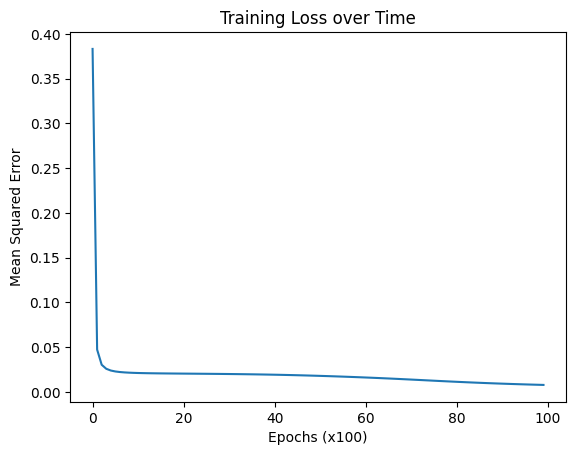

In [19]:
plt.plot(loss_curve)
plt.title("Training Loss over Time")
plt.xlabel("Epochs (x100)")
plt.ylabel("Mean Squared Error")
plt.show()